<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-19-April-7-2026/Lecture-19_NeuralNetwork-OnMeltingPointDataset-ImprovedVersion_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 19 - Neural Network Modelling on Melting Point Dataset - Improved Version

Here we are going to fit a deep neural network on the Bradley Melting Point Dataset, which is curated chemical dataset with melting points of around 3,000 chemical compounds, see [here](https://www.kaggle.com/datasets/aliffaagnur/melting-point-chemical-dataset/data).




Install RDKit and [LightGBM](https://lightgbm.readthedocs.io/en/stable/)

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit lightgbm mols2grid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.8 MB/s eta 0:00:00


Import all basic pacakges

In [2]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RDkit
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# For progress bar
from tqdm.auto import tqdm

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

# LightGBM
from lightgbm import LGBMRegressor, plot_importance


tqdm.pandas()

Download dataset

In [3]:
# Bash script to download all the dataset. Don't worry if you don't understand it
%%bash

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Assignment-2/"
dataset_filename="BradleyDoublePlusGoodMeltingPointDataset.csv"

rm -f ${dataset_filename}

wget ${url}/${dataset_filename} &> /dev/null

ls

BradleyDoublePlusGoodMeltingPointDataset.csv
sample_data


Read dataset

In [4]:
data_mp = pd.read_csv("BradleyDoublePlusGoodMeltingPointDataset.csv")



In [5]:
data_mp

,key,name,smiles,mpC,csid,link,source,count,min,max,range
0,27956,cyclobutylmethane,C1(CCC1)C,-161.51,11232,http://pubs.acs.org/doi/abs/10.1021/ja01142a048,Lemaire HP; Livingston RL Journal of the Ameri...,2,-161.51,-161.5,0.01
1,16005,Nitrogen oxide,[O-][N+]#N,-90.80,923,http://msds.chem.ox.ac.uk/,academic website,2,-90.81,-90.8,0.01
2,16127,Sulfuryl difluoride,FS(F)(=O)=O,-135.80,16647,http://msds.chem.ox.ac.uk/,academic website,2,-135.82,-135.8,0.02
3,17138,disopyramide,CC(C)N(CCC(c1ccccn1)(c2ccccc2)C(N)=O)C(C)C,94.80,3002,http://dx.doi.org/10.1021/ci700307p,Hughes LD; Palmer DS; Nigsch F and Mitchell JB...,2,94.75,94.8,0.05
4,15628,Bromine,BrBr,-7.20,22817,http://msds.chem.ox.ac.uk/,academic website,2,-7.25,-7.2,0.05
...,...,...,...,...,...,...,...,...,...,...,...
3036,27698,4-Nitrobenzoic acid,C1=CC(=CC=C1C(=O)O)[N+](=O)[O-],240.00,5882,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,6,237.00,242.0,5.00
3037,28584,Thalidomide,C1CC(=O)NC(=O)C1N2C(=O)C3=CC=CC=C3C2=O,275.00,5233,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,7,270.00,275.0,5.00
3038,28068,Estradiol,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3...,176.00,5554,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,7,173.00,178.0,5.00
3039,27580,"2,4,6-Trichlorophenol",C1=C(C=C(C(=C1Cl)O)Cl)Cl,65.00,21106172,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,9,65.00,70.0,5.00


In [6]:
# Simplify by removing columns from the data frame
data_mp = data_mp.drop(columns=['csid','link','source','count','min','max','range'])

In [7]:
property_names = list(rdMolDescriptors.Properties.GetAvailableProperties())
property_getter = rdMolDescriptors.Properties(property_names)

In [8]:
def smi2props(smi):
    mol = Chem.MolFromSmiles(smi)
    props = None
    if mol:
        props = np.array(property_getter.ComputeProperties(mol))
    return props

In [9]:
# one to the calculations for all smiles strings
data_mp['props'] = data_mp.smiles.progress_apply(smi2props)
data_mp = data_mp.dropna(subset=['props'])
data_mp[property_names] = data_mp['props'].tolist()
data_mp.drop("props",axis=1,inplace=True)

  0%|          | 0/3041 [00:00<?, ?it/s]

[16:04:47] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[16:04:47] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
[16:04:47] Can't kekulize mol.  Unkekulized atoms: 24 25 26 27 28 31 32 33 34
[16:04:47] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[16:04:47] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:04:47] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:04:47] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 24
[16:04:48] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[16:04:48] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 8
[16:04:48] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:04:49] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:04:49] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:04:49] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 12 13 14 15 16
[16:04:49] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:04:49] Can't kekulize mol.  Unkekuliz

### Visualize Features and Target

## Train using LightGBM

In [10]:
train, test = train_test_split(data_mp,test_size=0.20)

In [11]:
train_X = train[property_names]
train_y = train.mpC
test_X = test[property_names]
test_y = test.mpC

In [12]:
lgbm = LGBMRegressor()
lgbm.fit(train_X, train_y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000636 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5666
[LightGBM] [Info] Number of data points in the train set: 2420, number of used features: 42
[LightGBM] [Info] Start training from score 61.528285


LGBMRegressor()

In [13]:
test_pred = lgbm.predict(test_X)
train_pred = lgbm.predict(train_X)

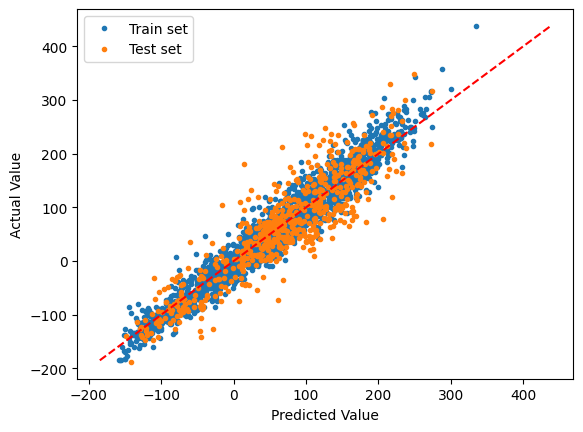

In [14]:
plt.plot(train_pred,train_y,'.',label='Train set')
plt.plot(test_pred,test_y,'.',label='Test set')
# to get a diagonal line
diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
# plt.axline([0, 0], slope=1, color='red', linestyle='--')
plt.legend()
plt.ylabel("Actual Value")
plt.xlabel("Predicted Value")

plt.show()

In [ ]:
print(train_X.shape)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

In [16]:
# Check if CUDA is available
print(torch.cuda.is_available())  # True = GPU available

# See which device you're on
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # 'cuda' or 'cpu'

# Get GPU name (if available)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))  # e.g. 'NVIDIA GeForce RTX 3090'
    print(torch.cuda.device_count())      # Number of GPUs

True
cuda
NVIDIA A100-SXM4-40GB
1


In [17]:
class DeepNet(nn.Module):
    def __init__(self, input_dim: int,
                 output_dim: int = 1,
                 hidden_dim: int = 128,
                 n_layers: int = 6):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

        # Xavier init for faster convergence
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [18]:
train_X_t = torch.tensor(train_X.values, dtype=torch.float32)
train_y_t = torch.tensor(train_y.values, dtype=torch.float32).unsqueeze(1)
test_X_t = torch.tensor(test_X.values, dtype=torch.float32)
test_y_t = torch.tensor(test_y.values, dtype=torch.float32).unsqueeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # 'cuda' or 'cpu'

# put the tensors onto the GPU for faster training
train_X_t = train_X_t.to(device)
train_y_t = train_y_t.to(device)
test_X_t = test_X_t.to(device)
test_y_t = test_y_t.to(device)



cuda


In [19]:
print(test_y_t.shape)

torch.Size([605, 1])


In [29]:
def regularization_loss(model: nn.Module, reg_type: str | None, LAMBDA_L1, LAMBDA_L2) -> torch.Tensor:
    """Return the regularization penalty for all weight tensors (biases excluded)."""
    if reg_type is None:
        return torch.tensor(0.0)

    weights = [p for name, p in model.named_parameters() if "weight" in name]

    if reg_type == "L1":
        return LAMBDA_L1 * sum(p.abs().sum() for p in weights)

    if reg_type == "L2":
        return LAMBDA_L2 * sum(p.pow(2).sum() for p in weights)

    if reg_type == "ElasticNet":
        l1 = LAMBDA_L1 * sum(p.abs().sum() for p in weights)
        l2 = LAMBDA_L2 * sum(p.pow(2).sum() for p in weights)
        return l1 + l2

    raise ValueError(f"Unknown reg_type '{reg_type}'. Choose None, 'L1', 'L2', or 'ElasticNet'.")

In [28]:
def do_training(EPOCHS=10_000, LR=1e-3 , REG_TYPE=None):

  input_dim = train_X.shape[1]
  print(input_dim)

  model = DeepNet(input_dim=input_dim, hidden_dim=128, n_layers=4)

  # put the model onto the GPU for faster training
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)

  print(model)
  total_params = sum(p.numel() for p in model.parameters())
  print(f"\nTotal parameters: {total_params:,}\n")

  EPOCHS    = EPOCHS
  LR        = LR
  SCHEDULER_PATIENCE = 300

  # ── Regularization config ─────────────────────────────────────────────────────
  # Set REG_TYPE to: None | "L1" | "L2" | "ElasticNet"
  REG_TYPE   = REG_TYPE      # None | "L1" | "L2" | "ElasticNet"
  LAMBDA_L1  = 1e-4       # L1 penalty weight  (used for L1 and ElasticNet)
  LAMBDA_L2  = 1e-4       # L2 penalty weight  (used for L2 and ElasticNet)


  reg_label = REG_TYPE if REG_TYPE else "None"
  print(f"Regularization : {reg_label}")
  if REG_TYPE in ("L1", "ElasticNet"):
      print(f"  λ_L1 = {LAMBDA_L1}")
  if REG_TYPE in ("L2", "ElasticNet"):
      print(f"  λ_L2 = {LAMBDA_L2}")
  print()

  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=LR)
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, patience=SCHEDULER_PATIENCE, factor=0.5
  )

  loss_history      = []   # total loss  (MSE + penalty)
  mse_history       = []   # data term only
  reg_loss_history  = []   # penalty term only

  loss_test_history      = []   # total loss  (MSE + penalty)
  mse_test_history       = []   # data term only
  reg_test_loss_history  = []   # penalty term only

  for epoch in range(1, EPOCHS + 1):
      # set the NN to training mode
      model.train()
      # set gradient to zero
      optimizer.zero_grad()

      # calculate the loss
      pred     = model(train_X_t)
      mse_loss = criterion(pred, train_y_t)
      reg_loss = regularization_loss(model, REG_TYPE,LAMBDA_L1=LAMBDA_L1, LAMBDA_L2=LAMBDA_L2)
      loss     = mse_loss + reg_loss

      # calculate the loss of the testing data
      pred_test     = model(test_X_t)
      mse_loss_test = criterion(pred_test, test_y_t)
      reg_loss_test = regularization_loss(model, REG_TYPE,LAMBDA_L1=LAMBDA_L1, LAMBDA_L2=LAMBDA_L2)
      loss_test     = mse_loss_test + reg_loss_test

      # calculate the gradient of the loss
      loss.backward()
      # update the parameters based on the loss
      optimizer.step()
      scheduler.step(loss)

      #
      loss_history.append(loss.item())
      mse_history.append(mse_loss.item())
      reg_loss_history.append(reg_loss.item())

      loss_test_history.append(loss_test.item())
      mse_test_history.append(mse_loss_test.item())
      reg_test_loss_history.append(reg_loss_test.item())

      if epoch % 500 == 0:
          print(f"Epoch {epoch:5d}/{EPOCHS} | Total: {loss.item():.6f} | "
                f"MSE: {mse_loss.item():.6f} | Reg ({reg_label}): {reg_loss.item():.6f} | "
                f"LR: {optimizer.param_groups[0]['lr']:.2e}")
  return model, loss_history, loss_test_history, mse_history, mse_test_history




In [22]:
def make_plots(model, loss_history, loss_test_history, mse_history=None, mse_test_history=None):
  plt.plot(loss_test_history, label='Total - Test set')
  plt.plot(loss_history, label='Total - Train set')


  if mse_history is not None:
    plt.plot(mse_test_history, label='MSE - Test set')
    plt.plot(mse_history, label='MSE - Train set')


  plt.yscale('log')
  plt.legend()
  plt.ylabel("Loss")
  plt.xlabel("Epoch")
  plt.show()

  model.eval()
  with torch.no_grad():
      pred_test_y_t   = model(test_X_t)
      pred_train_y_t   = model(train_X_t)

  # need to use .cpu() on the tensors to move them from GPU to CPU memory
  plt.plot(pred_test_y_t.cpu(),test_y_t.cpu(),  '.',label='Test set')
  plt.plot(pred_train_y_t.cpu(),train_y_t.cpu(),'.',label='Train set')
  # to get a diagonal line
  diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
  plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
  # plt.axline([0, 0], slope=1, color='red', linestyle='--')
  plt.legend()
  plt.xlabel("Predicted Value")
  plt.ylabel("Actual Value")
  plt.show()

  plt.plot(pred_test_y_t.cpu(),test_y_t.cpu()-pred_test_y_t.cpu(),  '.',label='Test set')
  plt.plot(pred_train_y_t.cpu(),train_y_t.cpu()-pred_train_y_t.cpu(),'.',label='Train set')
  plt.axhline(0, color='black', linewidth=1)
  plt.legend()
  plt.xlabel("Predicted Value")
  plt.ylabel("Residual (Actual-Predicted)")
  plt.show()

  sns.kdeplot(test_y_t.cpu()-pred_test_y_t.cpu(),label='Test set')
  plt.axvline(0, color='black', linewidth=1)
  plt.legend()
  plt.show()

  sns.kdeplot(train_y_t.cpu()-pred_train_y_t.cpu(),label='Train set')
  plt.axvline(0, color='black', linewidth=1)
  plt.legend()
  plt.show()



## Training without any regularization

In [24]:
model, loss_history, loss_test_history, mse_history, mse_test_history = do_training(EPOCHS=20000)

43
DeepNet(
  (net): Sequential(
    (0): Linear(in_features=43, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 55,297

Regularization : None



/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch   500/20000 | Total: 4422.708008 | MSE: 4422.708008 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  1000/20000 | Total: 2582.738281 | MSE: 2582.738281 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  1500/20000 | Total: 1771.198120 | MSE: 1771.198120 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  2000/20000 | Total: 1462.985352 | MSE: 1462.985352 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  2500/20000 | Total: 1132.552734 | MSE: 1132.552734 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  3000/20000 | Total: 1011.002075 | MSE: 1011.002075 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  3500/20000 | Total: 928.809937 | MSE: 928.809937 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  4000/20000 | Total: 815.257935 | MSE: 815.257935 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  4500/20000 | Total: 826.993286 | MSE: 826.993286 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  5000/20000 | Total: 611.381287 | MSE: 611.381287 | Reg (None): 0.000000 | LR: 1.00e-03
Epoch  5500/20000 | Total: 569.054016 | MSE: 569

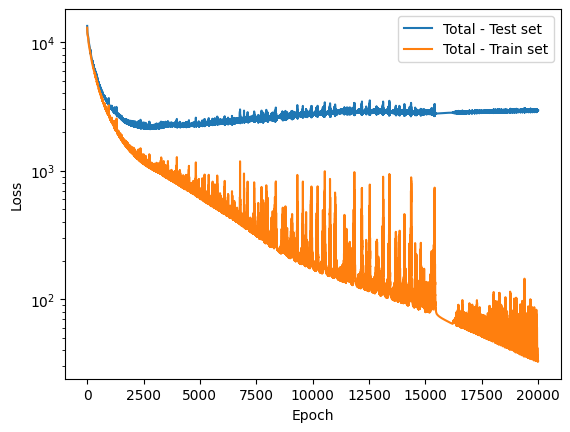

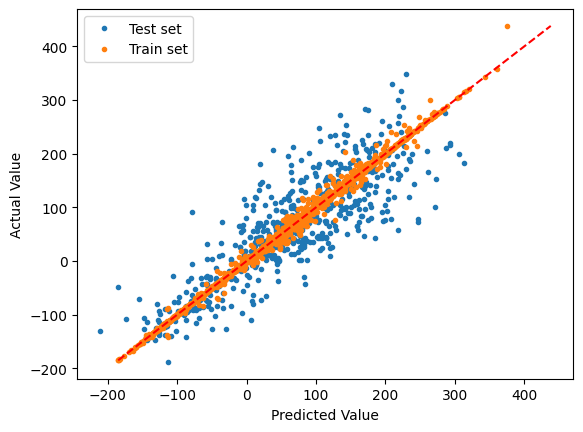

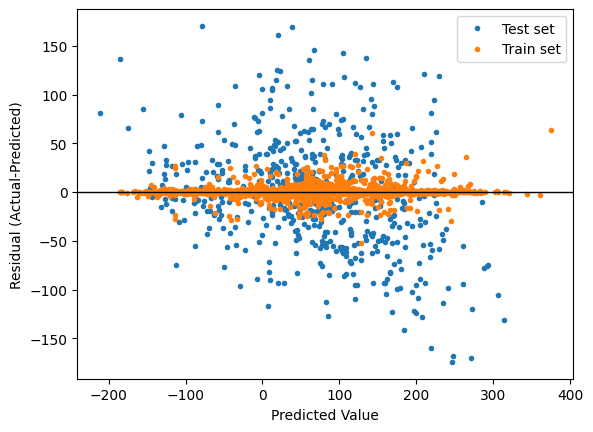

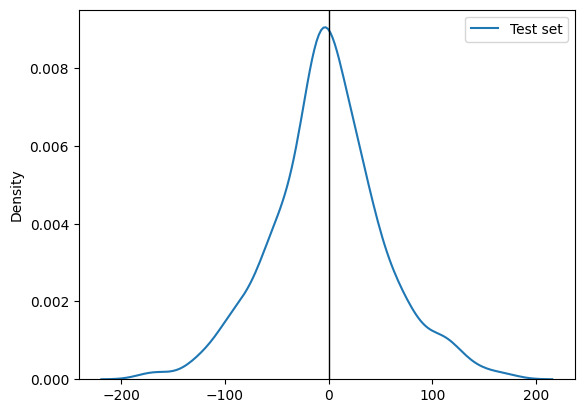

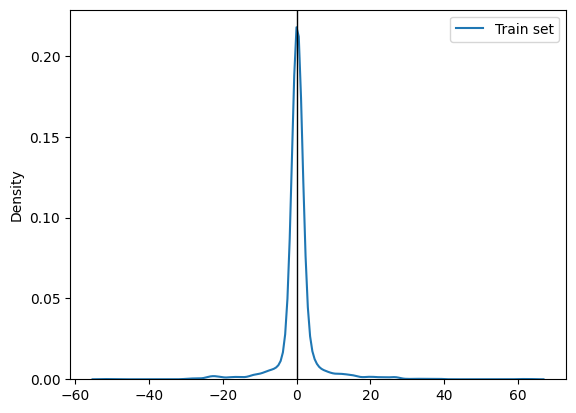

In [25]:
make_plots(model, loss_history, loss_test_history, mse_history=None, mse_test_history=None)

## Training with L2 regularization

In [30]:
model, loss_history, loss_test_history, mse_history, mse_test_history = do_training(EPOCHS=20000, REG_TYPE='L2')

43
DeepNet(
  (net): Sequential(
    (0): Linear(in_features=43, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 55,297

Regularization : L2
  λ_L2 = 0.0001

Epoch   500/20000 | Total: 4352.212402 | MSE: 4352.151855 | Reg (L2): 0.060751 | LR: 1.00e-03
Epoch  1000/20000 | Total: 2502.226562 | MSE: 2502.147461 | Reg (L2): 0.079081 | LR: 1.00e-03
Epoch  1500/20000 | Total: 1820.312988 | MSE: 1820.217407 | Reg (L2): 0.095622 | LR: 1.00e-03
Epoch  2000/20000 | Total: 1467.578613 | MSE: 1467.468018 | Reg (L2): 0.110607 | LR: 1.00e-03
Epoch  2500/20000 | Total: 1180.006958 | MSE: 1179.877441 | Reg (L2): 0.129541 | LR: 1.00e-03
Epoch  3000/20000 | Total: 1029.465088 | MSE: 1029.31420

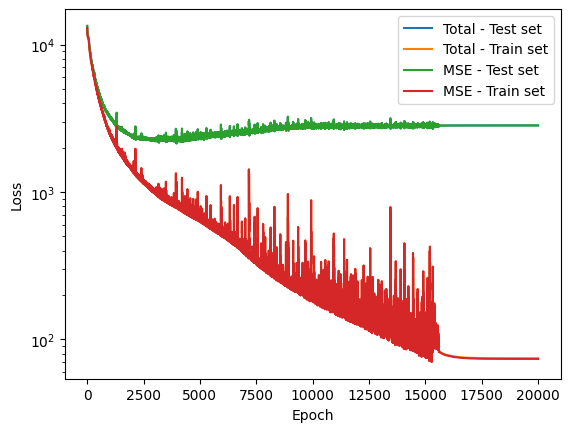

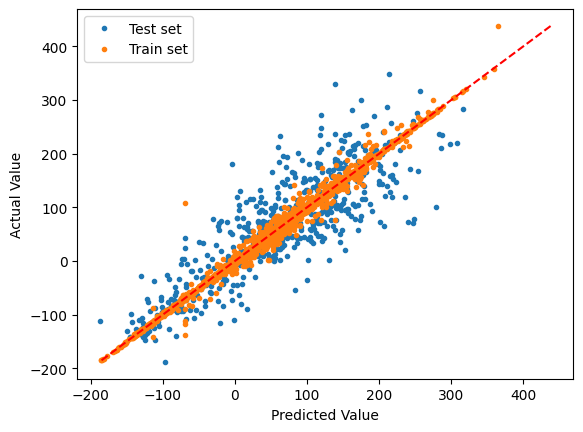

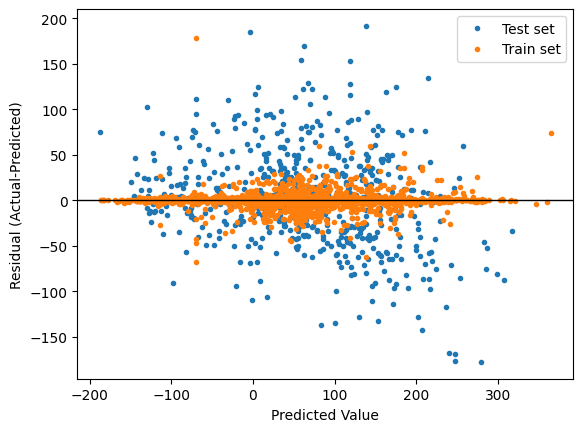

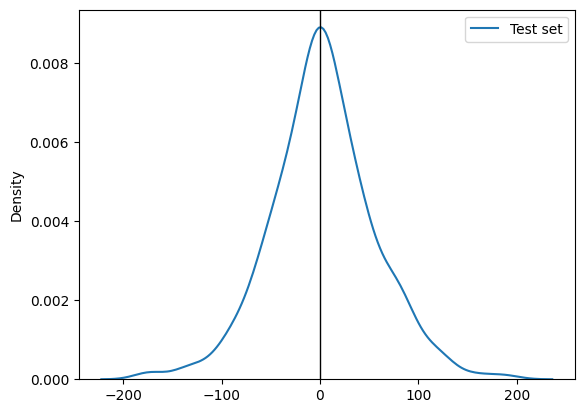

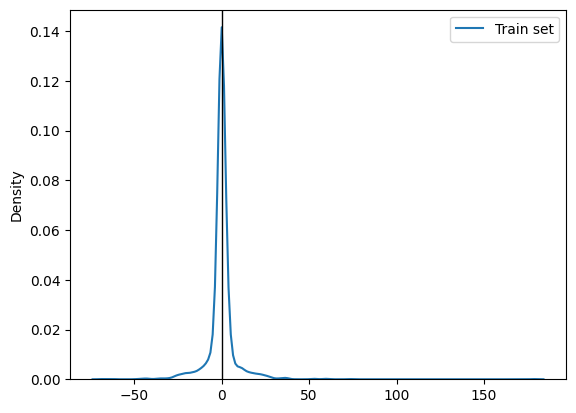

In [31]:
make_plots(model, loss_history, loss_test_history, mse_history=mse_history, mse_test_history=mse_test_history)